In [ ]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

RESULTS = Path('../results')
DETECTORS = ['mahal', 'gmm']
DOMAINS   = ['synthetic', 'lightbox', 'sunlamp']
DETECTOR_LABELS = {'mahal': 'Mahalanobis', 'gmm': 'GMM'}
DOMAIN_COLORS   = {'synthetic': '#4C72B0', 'lightbox': '#DD8452', 'sunlamp': '#55A868'}

def signed_log(scores):
    # from calibration.py
    return np.sign(scores) * np.log1p(np.abs(scores))

def load(detector, domain):
    scores = np.load(RESULTS / f'anomaly_scores_{detector}_{domain}.npy')
    errors = pd.read_csv(RESULTS / f'per_image_errors_{domain}.csv')['speed_score'].values
    n = min(len(scores), len(errors))
    return signed_log(scores[:n]), errors[:n]


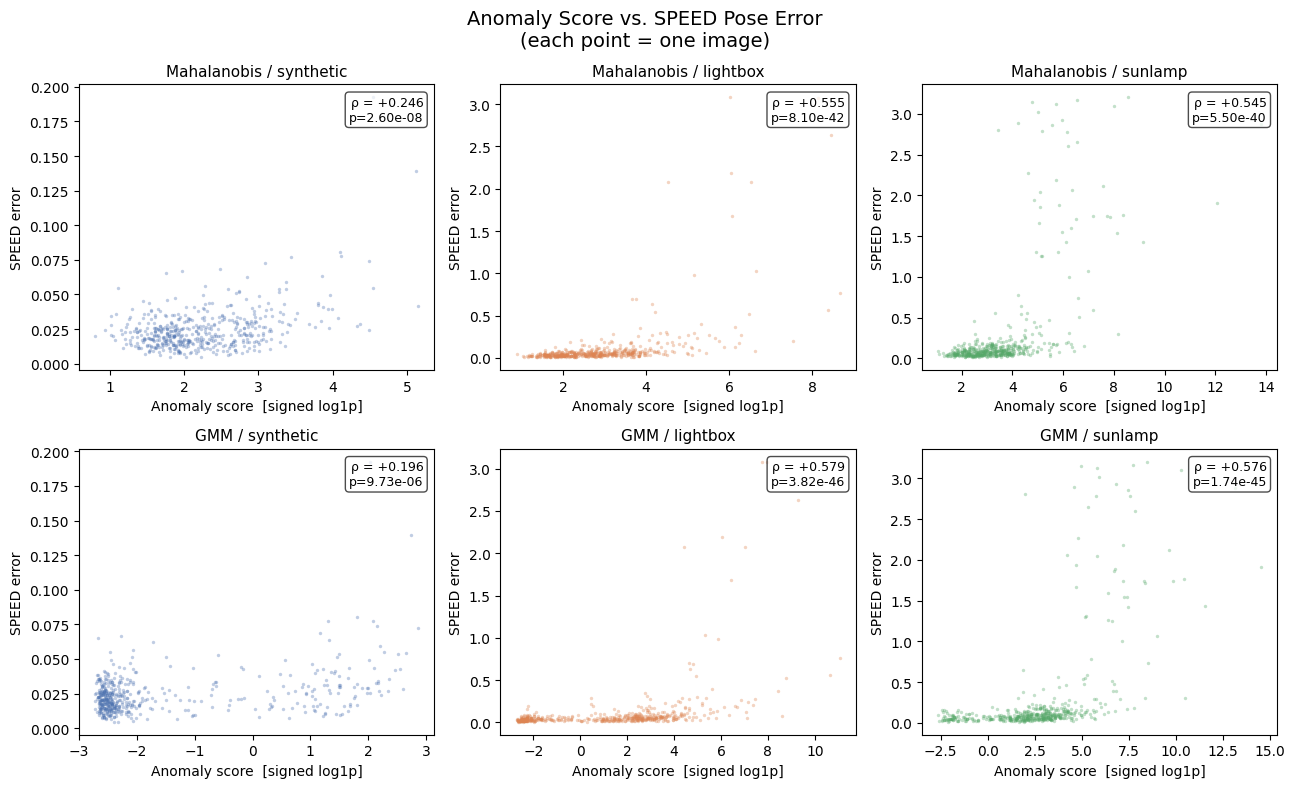

Saved → figures/score_error_correlation.png


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=False)
fig.suptitle('Anomaly Score vs. SPEED Pose Error\n(each point = one image)', fontsize=14)

for row, det in enumerate(DETECTORS):
    for col, dom in enumerate(DOMAINS):
        ax = axes[row, col]
        scores, errors = load(det, dom)
        rho, pval = spearmanr(scores, errors)
        ax.scatter(scores, errors, s=6, alpha=0.35, color=DOMAIN_COLORS[dom], linewidths=0)
        ax.set_xlabel('Anomaly score  [signed log1p]', fontsize=10)
        ax.set_ylabel('SPEED error', fontsize=10)
        ax.set_title(f'{DETECTOR_LABELS[det]} / {dom}', fontsize=11)
        sign = '+' if rho >= 0 else ''
        pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
        ax.text(0.97, 0.96, f'\u03c1 = {sign}{rho:.3f}\n{pstr}',
                transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig('../figures/score_error_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved \u2192 figures/score_error_correlation.png')


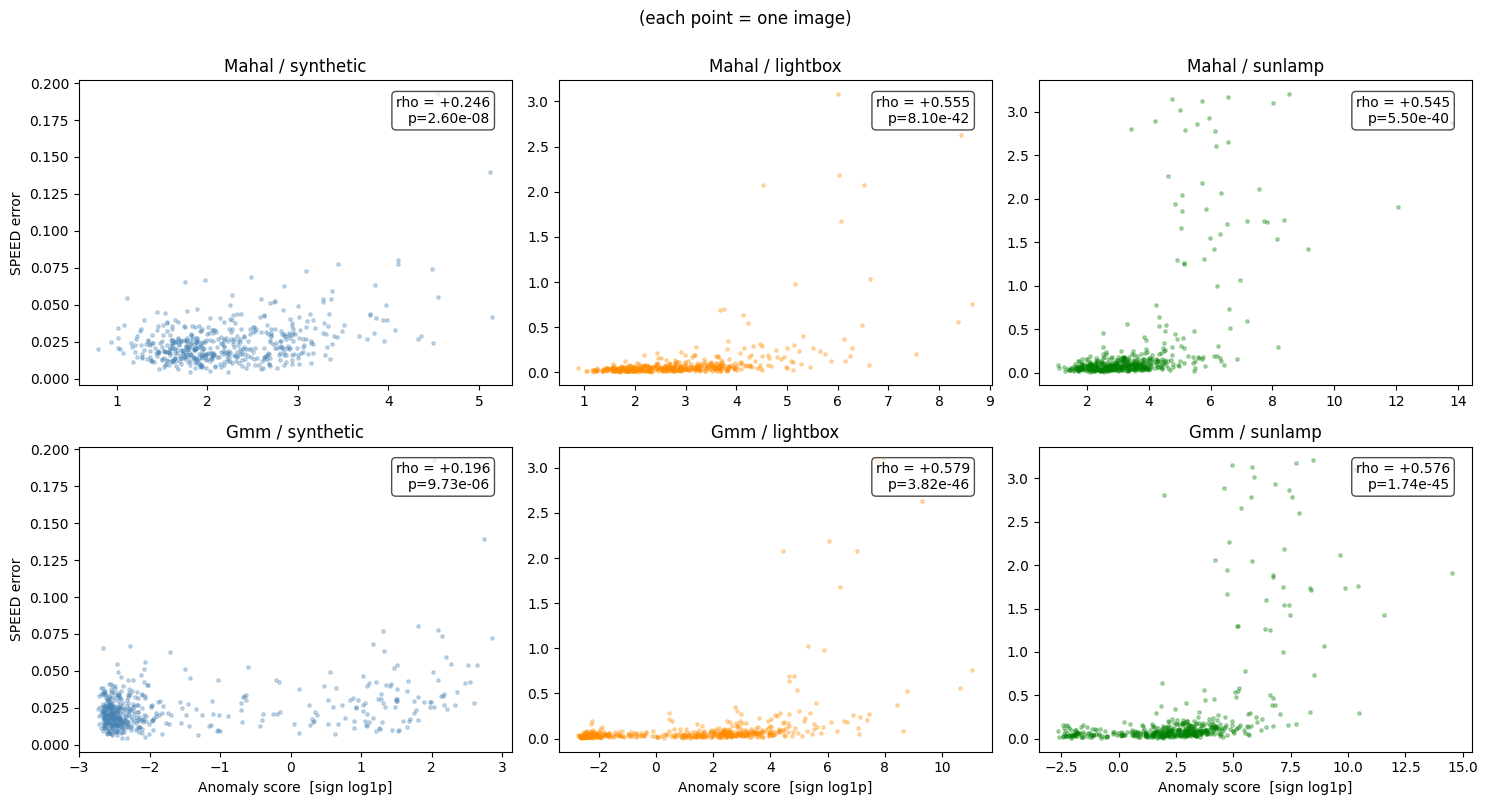

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for r, det in enumerate(DETECTORS):
    for c, dom in enumerate(DOMAINS):
        scores, err = load(det, dom)
        ax = axes[r, c]
        ax.scatter(scores, err, s=6, alpha=0.3,
                   color=['steelblue','darkorange','green'][c])
        rho, p = spearmanr(scores, err)
        ax.text(0.95, 0.95, f'rho = {rho:+.3f}\np={p:.2e}',
                transform=ax.transAxes, ha='right', va='top',
                fontsize=10, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        ax.set_title(f'{det.capitalize()} / {dom}')
        if r == 1: ax.set_xlabel('Anomaly score  [sign log1p]')
        if c == 0: ax.set_ylabel('SPEED error')

plt.suptitle('(each point = one image)', y=1.00)
plt.tight_layout()
plt.show()
